In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Chemin vers les données
data_path = os.path.expanduser('~/Desktop/football-intelligence/data/')

# Chargement des datasets principaux
players = pd.read_csv(data_path + 'players.csv')
valuations = pd.read_csv(data_path + 'player_valuations.csv')
transfers = pd.read_csv(data_path + 'transfers.csv')
appearances = pd.read_csv(data_path + 'appearances.csv')

# Aperçu général
print("=== PLAYERS ===")
print(f"Lignes: {players.shape[0]} | Colonnes: {players.shape[1]}")
print(players.head(3))

print("\n=== VALUATIONS ===")
print(f"Lignes: {valuations.shape[0]} | Colonnes: {valuations.shape[1]}")
print(valuations.head(3))

print("\n=== TRANSFERS ===")
print(f"Lignes: {transfers.shape[0]} | Colonnes: {transfers.shape[1]}")
print(transfers.head(3))

print("\n=== APPEARANCES ===")
print(f"Lignes: {appearances.shape[0]} | Colonnes: {appearances.shape[1]}")
print(appearances.head(3))

=== PLAYERS ===
Lignes: 47623 | Colonnes: 26
   player_id first_name     last_name                name  last_season  \
0         10   Miroslav         Klose      Miroslav Klose         2015   
1         26      Roman  Weidenfeller  Roman Weidenfeller         2017   
2         65    Dimitar      Berbatov    Dimitar Berbatov         2015   

   current_club_id         player_code country_of_birth city_of_birth  \
0              398      miroslav-klose           Poland         Opole   
1               16  roman-weidenfeller          Germany          Diez   
2             1091    dimitar-berbatov         Bulgaria   Blagoevgrad   

  country_of_citizenship  ...            agent_name  \
0                Germany  ...  ASBW Sport Marketing   
1                Germany  ...      Neubauer 13 GmbH   
2               Bulgaria  ...       CSKA-AS-23 Ltd.   

                                           image_url international_caps  \
0  https://img.a.transfermarkt.technology/portrai...                N

In [4]:
# Résumé des données
print("=== RÉSUMÉ GÉNÉRAL ===\n")

datasets = {
    'Players': players,
    'Valuations': valuations, 
    'Transfers': transfers,
    'Appearances': appearances
}

for name, df in datasets.items():
    print(f"📊 {name}")
    print(f"   Lignes: {df.shape[0]:,} | Colonnes: {df.shape[1]}")
    print(f"   Valeurs manquantes: {df.isnull().sum().sum():,}")
    print()

# Valeur marchande max
print("=== TOP 5 VALEURS MARCHANDES ===")
top_val = valuations.sort_values('market_value_in_eur', ascending=False).head()
print(top_val[['player_id', 'market_value_in_eur', 'date']].to_string())

=== RÉSUMÉ GÉNÉRAL ===

📊 Players
   Lignes: 47,623 | Colonnes: 26
   Valeurs manquantes: 198,402

📊 Valuations
   Lignes: 532,693 | Colonnes: 6
   Valeurs manquantes: 21,600

📊 Transfers
   Lignes: 42,570 | Colonnes: 10
   Valeurs manquantes: 31,737

📊 Appearances
   Lignes: 1,840,339 | Colonnes: 13
   Valeurs manquantes: 2

=== TOP 5 VALEURS MARCHANDES ===
        player_id  market_value_in_eur        date
515997     937958            200000000  2025-06-09
526129     937958            200000000  2025-12-12
296130     342229            200000000  2019-12-19
525672     342229            200000000  2025-12-12
271486     342229            200000000  2019-06-03


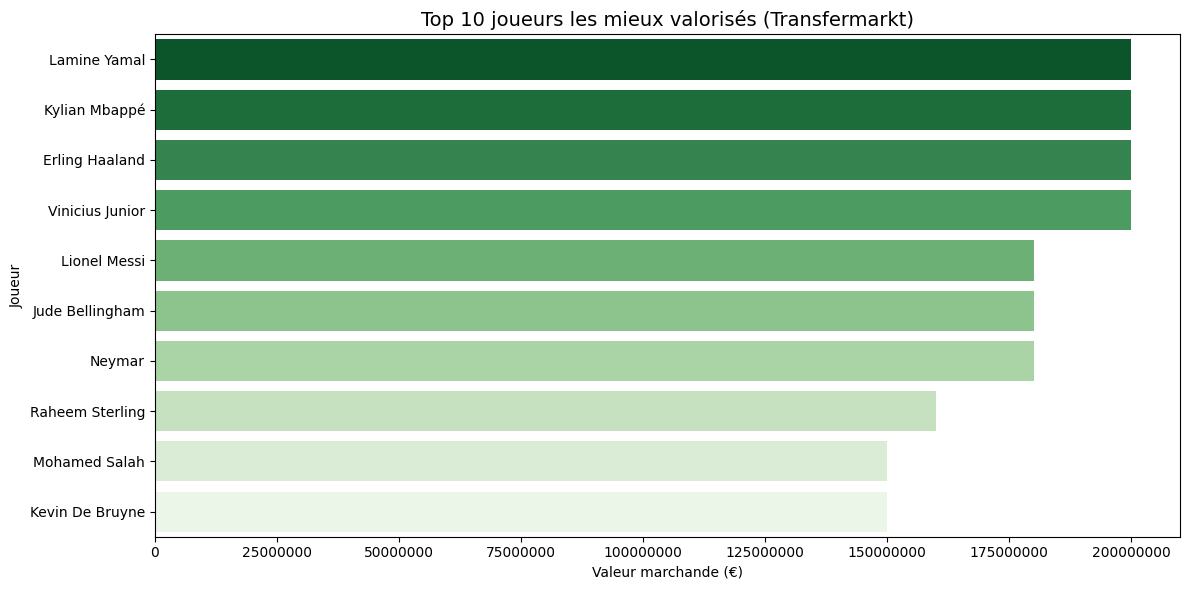

✅ Graphique sauvegardé !


In [6]:
import os

# Trouver les noms des joueurs les mieux valorisés
top_players = valuations.sort_values('market_value_in_eur', ascending=False).drop_duplicates('player_id').head(10)
top_players = top_players.merge(players[['player_id', 'name']], on='player_id', how='left')

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(data=top_players, x='market_value_in_eur', y='name', hue='name', palette='Greens_r', legend=False)
plt.title('Top 10 joueurs les mieux valorisés (Transfermarkt)', fontsize=14)
plt.xlabel('Valeur marchande (€)')
plt.ylabel('Joueur')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()

# Sauvegarde avec chemin absolu
save_path = os.path.expanduser('~/Desktop/football-intelligence/data/top10_valuations.png')
plt.savefig(save_path, dpi=150)
plt.show()
print("✅ Graphique sauvegardé !")